# Testes por filtro — métricas e correlações



## 1. Imports e caminhos

In [1]:
from pathlib import Path
import re

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

IRT_DIR = Path(r"C:\Users\User\Documents\Mestrado\UFPE\IRT")
TREINO_DIR = IRT_DIR / "treino"
OUTPUT_DIR = IRT_DIR / "correlacoes"
OUTPUT_DIR.mkdir(exist_ok=True)

CACHE_TEST = TREINO_DIR / "test_df.parquet"
CACHE_RESULTS = TREINO_DIR / "results_df.parquet"
CACHE_SPLIT_META = TREINO_DIR / "split_meta.joblib"

RANDOM_STATE = 42
MODEL_NAMES = [
    "LogisticRegression",
    "SVC_Linear",
    "SGD_Logistic",
    "SVC_RBF",
    "GaussianNB",
    "RandomForest",
    "DecisionTree",
    "QDA",
]


def slug_raca(raca: str) -> str:
    return re.sub(r"[^\w.-]+", "_", str(raca).strip())


def path_modelo(raca: str, modelo: str) -> Path:
    return TREINO_DIR / slug_raca(raca) / f"{modelo}.joblib"


## 2. Escolher a base de teste (filtro)

**`BASE_TESTE`**:

| valor | efeito |
|-------|--------|
| `"all"` | usa o `test_df` inteiro (todas as raças) |
| `"Black"`, `"White"`, … | filtra `test_df[race == …]` |



In [2]:
# >>> altere aqui <<<
BASE_TESTE = "all"  # "all" | "White" | "Black" | "Asian-Pac-Islander" | "Amer-Indian-Eskimo" | "Other"

PERCENTIL_MANTER = 50  # seção de descarte por concordância
N_AMOSTRA = 10
LINKAGE_METHOD = "average"


## 3. Carregar modelos, teste e métricas

In [3]:
faltando = [p for p in (CACHE_TEST, CACHE_RESULTS, CACHE_SPLIT_META) if not p.exists()]
if faltando:
    raise FileNotFoundError(
        "Artefatos ausentes em treino/. Rode irt_models_por_raca.ipynb primeiro:\n"
        + "\n".join(str(p) for p in faltando)
    )

split_meta = joblib.load(CACHE_SPLIT_META)
racas_validas = list(split_meta["racas_validas"])
feature_cols = list(split_meta["feature_cols"])

test_df_full = pd.read_parquet(CACHE_TEST)
results_df = pd.read_parquet(CACHE_RESULTS)

# --- filtro da base ---
if BASE_TESTE == "all":
    test_df = test_df_full.copy()
    label_base = "todas as raças"
    slug_base = "all"
else:
    if BASE_TESTE not in racas_validas:
        raise ValueError(f"BASE_TESTE={BASE_TESTE!r} inválida. Opções: 'all' ou {racas_validas}")
    test_df = test_df_full[test_df_full["race"] == BASE_TESTE].copy()
    label_base = f"raça = {BASE_TESTE}"
    slug_base = slug_raca(BASE_TESTE)

if len(test_df) < 2:
    raise ValueError(f"Base filtrada com poucas instâncias: {len(test_df)}")

# carregar pipelines
pipes = {}
for race in racas_validas:
    for name in MODEL_NAMES:
        p = path_modelo(race, name)
        if not p.exists():
            raise FileNotFoundError(f"Modelo ausente: {p}")
        pipes[(race, name)] = joblib.load(p)

print(f"Base de teste: {label_base} — {len(test_df)} instâncias (de {len(test_df_full)})")
print(f"Pipelines: {len(pipes)} | raças treino: {racas_validas}")
display(test_df["race"].value_counts().rename("n"))


Base de teste: todas as raças — 3257 instâncias (de 3257)
Pipelines: 40 | raças treino: ['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']


race
White                 2782
Black                  313
Asian-Pac-Islander     104
Amer-Indian-Eskimo      31
Other                   27
Name: n, dtype: int64

## 4. Métricas (salvas no treino)

Tabela de desempenho **por raça de treino**, no teste da própria raça (`tipo_teste = por_raca`).
Independe do filtro de instâncias — usa `results_df.parquet`.


In [4]:
por_raca_df = results_df[results_df["tipo_teste"] == "por_raca"].copy()
racas_cols = sorted(por_raca_df["raca"].unique())


def montar_tabela(metric):
    tab = por_raca_df.pivot(index="modelo", columns="raca", values=metric).round(3)
    return tab.reindex(columns=racas_cols)


print("=== Acurácia ===")
display(montar_tabela("acuracia"))

print("=== F1 ===")
display(montar_tabela("f1"))

print("=== ROC AUC ===")
display(montar_tabela("roc_auc"))

print("=== Melhor modelo por raça (ROC AUC) ===")
best = (
    por_raca_df.sort_values("roc_auc", ascending=False)
    .groupby("raca", observed=True)
    .first()[["modelo", "roc_auc", "acuracia", "f1", "n_teste"]]
)
display(best)


=== Acurácia ===


raca,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,Other,White
modelo,,,,,
DecisionTree,0.677,0.769,0.895,0.926,0.802
GaussianNB,0.613,0.365,0.355,0.667,0.515
LogisticRegression,0.903,0.865,0.927,0.889,0.845
QDA,0.839,0.846,0.904,0.889,0.837
RandomForest,0.806,0.856,0.930,0.926,0.844
SGD_Logistic,0.935,0.769,0.927,0.926,0.842
SVC_Linear,0.903,0.837,0.920,0.889,0.839
SVC_RBF,0.806,0.865,0.930,0.889,0.850


=== F1 ===


raca,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,Other,White
modelo,,,,,
DecisionTree,0.286,0.636,0.535,0.500,0.634
GaussianNB,0.538,0.468,0.217,0.182,0.510
LogisticRegression,0.727,0.741,0.596,0.400,0.685
QDA,0.444,0.742,0.531,0.000,0.699
RandomForest,0.250,0.754,0.593,0.500,0.687
SGD_Logistic,0.833,0.500,0.511,0.500,0.684
SVC_Linear,0.727,0.679,0.528,0.400,0.666
SVC_RBF,0.250,0.759,0.542,0.000,0.682


=== ROC AUC ===


raca,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,Other,White
modelo,,,,,
DecisionTree,0.539,0.755,0.778,0.667,0.754
GaussianNB,0.750,0.567,0.631,0.521,0.716
LogisticRegression,0.946,0.934,0.932,0.931,0.903
QDA,0.702,0.937,0.922,0.917,0.896
RandomForest,0.875,0.931,0.938,0.938,0.903
SGD_Logistic,0.929,0.842,0.924,0.986,0.902
SVC_Linear,0.958,0.922,0.932,0.944,0.899
SVC_RBF,0.881,0.949,0.925,0.944,0.899


=== Melhor modelo por raça (ROC AUC) ===


,modelo,roc_auc,acuracia,f1,n_teste
raca,,,,,
Amer-Indian-Eskimo,SVC_Linear,0.958,0.903,0.727,31
Asian-Pac-Islander,SVC_RBF,0.949,0.865,0.759,104
Black,RandomForest,0.938,0.930,0.593,313
Other,SGD_Logistic,0.986,0.926,0.500,27
White,LogisticRegression,0.903,0.845,0.685,2782


## 5. Métricas na base filtrada

Reavalia cada pipeline `(raça_treino, modelo)` **nas instâncias do filtro atual** — útil para ver como modelos de uma raça se comportam em outra (ou no conjunto completo).


In [5]:
def avaliar(pipe, X_te, y_te):
    pred = pipe.predict(X_te)
    try:
        proba = pipe.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, proba) if y_te.nunique() > 1 else np.nan
    except Exception:
        auc = np.nan

    tn, fp, fn, tp = confusion_matrix(y_te, pred, labels=[0, 1]).ravel()
    return {
        "n_teste": len(y_te),
        "acuracia": accuracy_score(y_te, pred),
        "f1": f1_score(y_te, pred, zero_division=0),
        "roc_auc": auc,
        "erro": (fp + fn) / len(y_te),
        "fpr": fp / (fp + tn) if (fp + tn) else np.nan,
        "fnr": fn / (fn + tp) if (fn + tp) else np.nan,
    }


X_te = test_df[feature_cols]
y_te = test_df["_target"]

rows = []
for race in racas_validas:
    for name in MODEL_NAMES:
        m = avaliar(pipes[(race, name)], X_te, y_te)
        rows.append({"raca_treino": race, "modelo": name, "base_teste": label_base, **m})

metrics_filtro = pd.DataFrame(rows).round(3)
print(f"Métricas na base filtrada: {label_base} (n={len(test_df)})")
display(metrics_filtro.pivot(index="modelo", columns="raca_treino", values="roc_auc").round(3))

print("\nPrévia completa:")
display(metrics_filtro.head(16))


Métricas na base filtrada: todas as raças (n=3257)


raca_treino,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,Other,White
modelo,,,,,
DecisionTree,0.630,0.722,0.738,0.657,0.760
GaussianNB,0.668,0.590,0.648,0.634,0.723
LogisticRegression,0.857,0.897,0.905,0.867,0.909
QDA,0.789,0.889,0.896,0.767,0.902
RandomForest,0.843,0.886,0.897,0.851,0.908
SGD_Logistic,0.818,0.827,0.903,0.788,0.908
SVC_Linear,0.816,0.886,0.903,0.847,0.904
SVC_RBF,0.787,0.888,0.896,0.813,0.902



Prévia completa:


,raca_treino,modelo,base_teste,n_teste,acuracia,f1,roc_auc,erro,fpr,fnr
0,Amer-Indian-Eskimo,LogisticRegression,todas as raças,3257,0.816,0.484,0.857,0.184,0.033,0.648
1,Amer-Indian-Eskimo,SVC_Linear,todas as raças,3257,0.811,0.500,0.816,0.189,0.050,0.615
2,Amer-Indian-Eskimo,SGD_Logistic,todas as raças,3257,0.807,0.517,0.818,0.193,0.068,0.579
3,Amer-Indian-Eskimo,SVC_RBF,todas as raças,3257,0.782,0.208,0.787,0.218,0.002,0.883
4,Amer-Indian-Eskimo,GaussianNB,todas as raças,3257,0.580,0.495,0.668,0.420,0.504,0.160
5,Amer-Indian-Eskimo,RandomForest,todas as raças,3257,0.802,0.374,0.843,0.198,0.016,0.758
6,Amer-Indian-Eskimo,DecisionTree,todas as raças,3257,0.781,0.428,0.630,0.219,0.073,0.667
7,Amer-Indian-Eskimo,QDA,todas as raças,3257,0.782,0.206,0.789,0.218,0.001,0.885
8,Asian-Pac-Islander,LogisticRegression,todas as raças,3257,0.841,0.646,0.897,0.159,0.077,0.410
9,Asian-Pac-Islander,SVC_Linear,todas as raças,3257,0.831,0.629,0.886,0.169,0.090,0.414


## 6. Amostra de probabilidades

Se o filtro for uma raça, usa os modelos treinados **nessa** raça.
Se for `"all"`, mostra uma amostra por raça presente no teste.


In [6]:
def amostra_probs(instancias, raca_treino, n=N_AMOSTRA):
    n = min(len(instancias), n)
    amostra = instancias.sample(n, random_state=RANDOM_STATE)
    tab = pd.DataFrame(index=amostra.index)
    tab["race"] = amostra["race"].values
    tab["real"] = amostra["_target"].values
    X = amostra[feature_cols]
    for name in MODEL_NAMES:
        tab[name] = pipes[(raca_treino, name)].predict_proba(X)[:, 1]
    return tab.round(3)


if BASE_TESTE == "all":
    for race in sorted(test_df["race"].unique()):
        subset = test_df[test_df["race"] == race]
        print(f"=== Amostra: instâncias {race} | modelos treinados em {race} ===")
        display(amostra_probs(subset, race))
else:
    print(f"=== Amostra: filtro {BASE_TESTE} | modelos treinados em {BASE_TESTE} ===")
    display(amostra_probs(test_df, BASE_TESTE))


=== Amostra: instâncias Amer-Indian-Eskimo | modelos treinados em Amer-Indian-Eskimo ===


,race,real,LogisticRegression,SVC_Linear,SGD_Logistic,SVC_RBF,GaussianNB,RandomForest,DecisionTree,QDA
19572,Amer-Indian-Eskimo,0,0.004,0.019,0.000,0.033,0.0,0.015,0.0,0.000
5775,Amer-Indian-Eskimo,0,0.026,0.041,0.000,0.037,0.0,0.020,0.0,0.000
28742,Amer-Indian-Eskimo,0,0.044,0.071,0.000,0.058,0.0,0.025,0.0,0.000
26093,Amer-Indian-Eskimo,1,0.514,0.329,1.000,0.168,1.0,0.280,0.0,0.000
13932,Amer-Indian-Eskimo,0,0.070,0.041,0.000,0.120,0.0,0.220,1.0,0.000
18442,Amer-Indian-Eskimo,0,0.146,0.132,0.000,0.065,1.0,0.445,1.0,0.000
18769,Amer-Indian-Eskimo,0,0.063,0.090,0.000,0.062,1.0,0.150,0.0,0.000
10983,Amer-Indian-Eskimo,1,0.065,0.143,0.000,0.052,1.0,0.095,0.0,0.000
6930,Amer-Indian-Eskimo,0,0.003,0.007,0.000,0.020,0.0,0.000,0.0,0.000
10269,Amer-Indian-Eskimo,1,0.988,0.901,0.997,0.687,1.0,0.560,1.0,0.999


=== Amostra: instâncias Asian-Pac-Islander | modelos treinados em Asian-Pac-Islander ===


,race,real,LogisticRegression,SVC_Linear,SGD_Logistic,SVC_RBF,GaussianNB,RandomForest,DecisionTree,QDA
27846,Asian-Pac-Islander,0,0.029,0.118,0.063,0.090,1.0,0.015,0.0,0.000
25002,Asian-Pac-Islander,0,0.016,0.020,0.021,0.065,0.0,0.050,0.0,0.000
5330,Asian-Pac-Islander,0,0.169,0.121,0.040,0.320,1.0,0.220,0.0,0.163
16528,Asian-Pac-Islander,0,0.035,0.052,0.087,0.067,1.0,0.095,0.0,0.001
12917,Asian-Pac-Islander,0,0.418,0.332,0.464,0.255,1.0,0.510,0.0,0.478
25421,Asian-Pac-Islander,0,0.107,0.139,0.044,0.200,1.0,0.085,0.0,0.048
26091,Asian-Pac-Islander,0,0.034,0.112,0.008,0.086,1.0,0.015,0.0,0.000
30338,Asian-Pac-Islander,0,0.579,0.611,0.183,0.723,1.0,0.655,1.0,0.966
19344,Asian-Pac-Islander,0,0.024,0.033,0.016,0.090,1.0,0.160,1.0,0.001
9848,Asian-Pac-Islander,0,0.068,0.154,0.264,0.091,0.0,0.165,0.0,0.000


=== Amostra: instâncias Black | modelos treinados em Black ===


,race,real,LogisticRegression,SVC_Linear,SGD_Logistic,SVC_RBF,GaussianNB,RandomForest,DecisionTree,QDA
29917,Black,0,0.030,0.045,0.008,0.082,1.000,0.030,0.0,0.006
7209,Black,0,0.016,0.018,0.004,0.026,1.000,0.000,0.0,0.000
185,Black,0,0.153,0.140,0.099,0.078,1.000,0.210,0.0,0.081
24420,Black,0,0.011,0.021,0.003,0.036,1.000,0.005,0.0,0.000
15463,Black,0,0.004,0.008,0.002,0.010,1.000,0.000,0.0,0.000
1424,Black,0,0.400,0.278,0.267,0.357,1.000,0.610,1.0,0.529
27288,Black,0,0.013,0.025,0.004,0.043,0.987,0.030,0.0,0.000
7904,Black,0,0.423,0.243,0.215,0.375,1.000,0.600,0.0,0.887
28160,Black,1,0.667,0.550,0.710,0.793,1.000,0.760,1.0,0.923
26931,Black,0,0.124,0.121,0.077,0.072,1.000,0.080,0.0,0.031


=== Amostra: instâncias Other | modelos treinados em Other ===


,race,real,LogisticRegression,SVC_Linear,SGD_Logistic,SVC_RBF,GaussianNB,RandomForest,DecisionTree,QDA
3453,Other,0,0.001,0.010,0.000,0.034,1.0,0.000,0.0,0.0
6878,Other,0,0.001,0.014,0.000,0.031,0.0,0.000,0.0,0.0
15992,Other,0,0.001,0.008,0.000,0.008,0.0,0.000,0.0,0.0
32075,Other,0,0.041,0.134,0.008,0.136,1.0,0.105,0.0,0.0
21502,Other,0,0.006,0.027,0.000,0.024,0.0,0.000,0.0,0.0
21531,Other,0,0.520,0.280,0.000,0.141,1.0,0.230,0.0,0.0
23822,Other,0,0.011,0.048,0.000,0.030,1.0,0.005,0.0,0.0
14779,Other,1,0.775,0.563,1.000,0.483,0.0,0.555,1.0,0.0
9869,Other,0,0.022,0.061,0.000,0.031,0.0,0.060,0.0,0.0
8516,Other,0,0.002,0.015,0.000,0.035,0.0,0.010,0.0,0.0


=== Amostra: instâncias White | modelos treinados em White ===


,race,real,LogisticRegression,SVC_Linear,SGD_Logistic,SVC_RBF,GaussianNB,RandomForest,DecisionTree,QDA
6079,White,0,0.002,0.005,0.001,0.093,0.00,0.000,0.0,0.000
8514,White,0,0.001,0.005,0.001,0.045,0.00,0.000,0.0,0.000
8107,White,0,0.129,0.083,0.112,0.141,1.00,0.090,0.0,0.006
22994,White,0,0.083,0.123,0.046,0.094,0.00,0.000,0.0,0.003
11348,White,0,0.008,0.014,0.004,0.118,0.00,0.000,0.0,0.000
12789,White,0,0.008,0.015,0.004,0.061,0.00,0.020,0.0,0.000
267,White,1,0.518,0.462,0.565,0.399,1.00,0.675,1.0,0.598
15153,White,1,0.036,0.093,0.034,0.135,0.06,0.025,0.0,0.001
18911,White,0,0.326,0.264,0.343,0.146,1.00,0.505,1.0,0.304
31631,White,0,0.725,0.766,0.683,0.895,1.00,0.910,1.0,0.904


## 7. Matriz de probabilidades (itens × instâncias)

Cada linha é um item `modelo@raça_treino` (40 itens).
As colunas são as **instâncias da base filtrada**.


In [7]:
def construir_matriz_probabilidades(instancias_df):
    """Matriz itens x instâncias com P(y=1 | x) para cada pipe (raca_treino, modelo)."""
    X = instancias_df[feature_cols]
    linhas = []
    indices = []
    for raca in sorted(racas_validas):
        for modelo in MODEL_NAMES:
            proba_pos = pipes[(raca, modelo)].predict_proba(X)[:, 1]
            linhas.append(proba_pos)
            indices.append(f"{modelo}@{raca}")
    return pd.DataFrame(linhas, index=indices, columns=instancias_df.index).round(3)


matriz_prob = construir_matriz_probabilidades(test_df)
meta_instancias = test_df[["race", "_target"]].rename(columns={"_target": "y_positivo"})

print(f"Matriz: {matriz_prob.shape[0]} itens x {matriz_prob.shape[1]} instâncias ({label_base})")
display(matriz_prob.iloc[:5, :5])
display(meta_instancias.head())

# cache opcional da matriz filtrada
CACHE_MATRIZ = OUTPUT_DIR / f"matriz_prob_{slug_base}.parquet"
CACHE_META = OUTPUT_DIR / f"meta_instancias_{slug_base}.parquet"
matriz_prob.T.to_parquet(CACHE_MATRIZ)
meta_instancias.to_parquet(CACHE_META)
print(f"Salvo: {CACHE_MATRIZ}")
print(f"Salvo: {CACHE_META}")


Matriz: 40 itens x 3257 instâncias (todas as raças)


,2232,6086,10568,4685,21310
LogisticRegression@Amer-Indian-Eskimo,0.011,0.133,0.390,0.065,0.018
SVC_Linear@Amer-Indian-Eskimo,0.045,0.112,0.161,0.109,0.057
SGD_Logistic@Amer-Indian-Eskimo,0.000,0.000,1.000,0.000,0.000
SVC_RBF@Amer-Indian-Eskimo,0.028,0.089,0.275,0.066,0.068
GaussianNB@Amer-Indian-Eskimo,1.000,1.000,1.000,1.000,1.000


,race,y_positivo
2232,Black,0
6086,White,0
10568,White,0
4685,White,1
21310,White,0


Salvo: correlacoes\matriz_prob_all.parquet
Salvo: correlacoes\meta_instancias_all.parquet


## 8. Matriz de correlação dos modelos

Correlação entre os 40 itens (`modelo@raça`) nas instâncias do filtro.
Também compara com cada raça **dentro** do filtro (se `BASE_TESTE == "all"`).



Base: todas as raças — 3257 instâncias | corr 40x40


,LogisticRegression@Amer-Indian-Eskimo,SVC_Linear@Amer-Indian-Eskimo,SGD_Logistic@Amer-Indian-Eskimo,SVC_RBF@Amer-Indian-Eskimo,GaussianNB@Amer-Indian-Eskimo,RandomForest@Amer-Indian-Eskimo,DecisionTree@Amer-Indian-Eskimo,QDA@Amer-Indian-Eskimo
LogisticRegression@Amer-Indian-Eskimo,1.000,0.944,0.718,0.887,0.362,0.853,0.580,0.543
SVC_Linear@Amer-Indian-Eskimo,0.944,1.000,0.640,0.854,0.352,0.805,0.551,0.632
SGD_Logistic@Amer-Indian-Eskimo,0.718,0.640,1.000,0.600,0.286,0.727,0.488,0.331
SVC_RBF@Amer-Indian-Eskimo,0.887,0.854,0.600,1.000,0.244,0.785,0.608,0.580
GaussianNB@Amer-Indian-Eskimo,0.362,0.352,0.286,0.244,1.000,0.406,0.202,0.101
RandomForest@Amer-Indian-Eskimo,0.853,0.805,0.727,0.785,0.406,1.000,0.638,0.433
DecisionTree@Amer-Indian-Eskimo,0.580,0.551,0.488,0.608,0.202,0.638,1.000,0.410
QDA@Amer-Indian-Eskimo,0.543,0.632,0.331,0.580,0.101,0.433,0.410,1.000


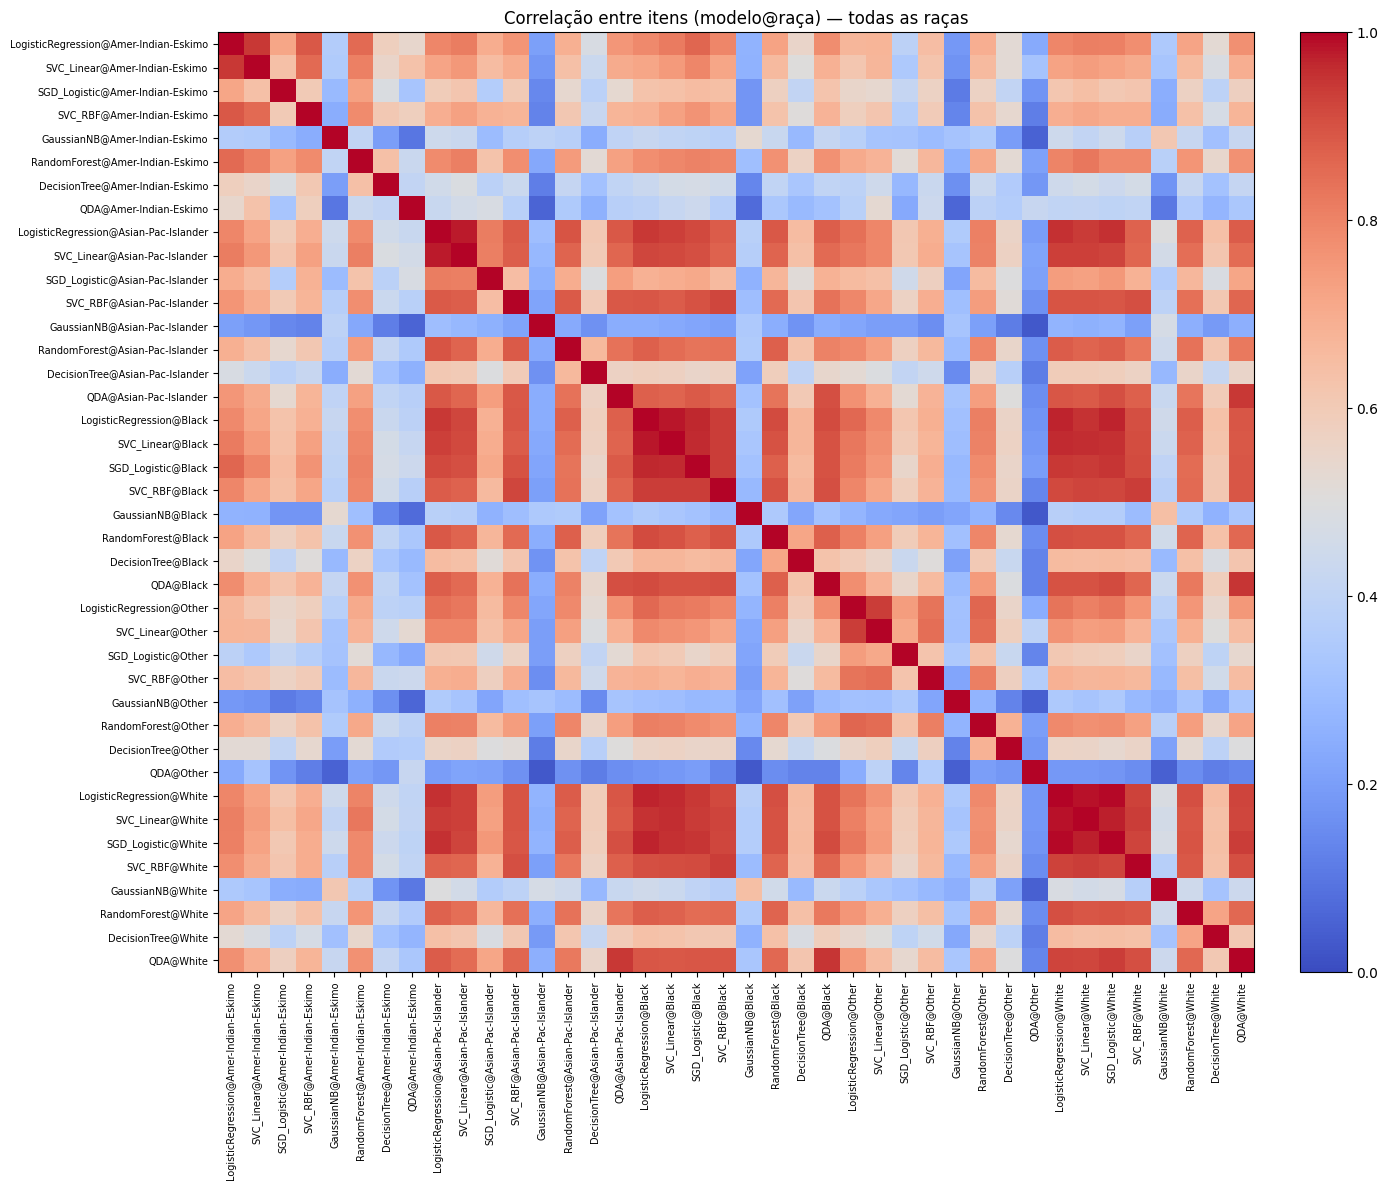

Exportado: correlacoes\corr_teste_all.csv

Base: Amer-Indian-Eskimo — 31 instâncias | corr 40x40


,LogisticRegression@Amer-Indian-Eskimo,SVC_Linear@Amer-Indian-Eskimo,SGD_Logistic@Amer-Indian-Eskimo,SVC_RBF@Amer-Indian-Eskimo,GaussianNB@Amer-Indian-Eskimo,RandomForest@Amer-Indian-Eskimo,DecisionTree@Amer-Indian-Eskimo,QDA@Amer-Indian-Eskimo
LogisticRegression@Amer-Indian-Eskimo,1.000,0.960,0.861,0.882,0.424,0.787,0.391,0.824
SVC_Linear@Amer-Indian-Eskimo,0.960,1.000,0.773,0.946,0.385,0.738,0.454,0.932
SGD_Logistic@Amer-Indian-Eskimo,0.861,0.773,1.000,0.724,0.349,0.676,0.182,0.598
SVC_RBF@Amer-Indian-Eskimo,0.882,0.946,0.724,1.000,0.254,0.657,0.492,0.961
GaussianNB@Amer-Indian-Eskimo,0.424,0.385,0.349,0.254,1.000,0.419,-0.046,0.209
RandomForest@Amer-Indian-Eskimo,0.787,0.738,0.676,0.657,0.419,1.000,0.685,0.572
DecisionTree@Amer-Indian-Eskimo,0.391,0.454,0.182,0.492,-0.046,0.685,1.000,0.486
QDA@Amer-Indian-Eskimo,0.824,0.932,0.598,0.961,0.209,0.572,0.486,1.000


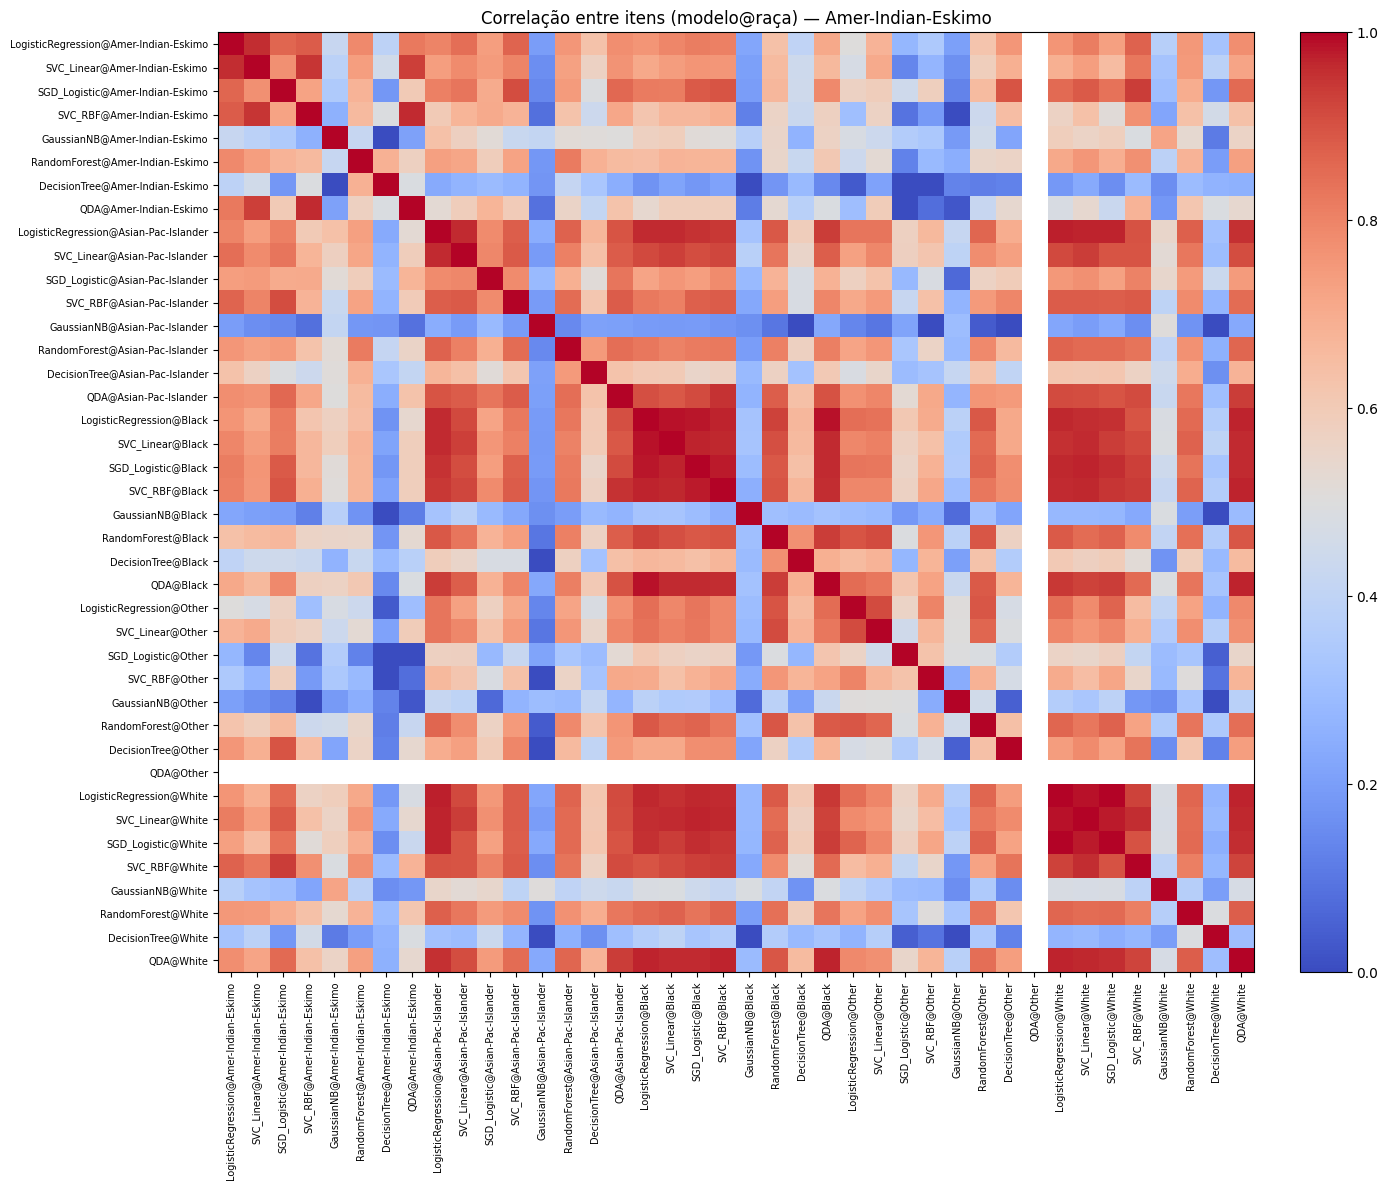

Exportado: correlacoes\corr_teste_Amer-Indian-Eskimo.csv

Base: Asian-Pac-Islander — 104 instâncias | corr 40x40


,LogisticRegression@Amer-Indian-Eskimo,SVC_Linear@Amer-Indian-Eskimo,SGD_Logistic@Amer-Indian-Eskimo,SVC_RBF@Amer-Indian-Eskimo,GaussianNB@Amer-Indian-Eskimo,RandomForest@Amer-Indian-Eskimo,DecisionTree@Amer-Indian-Eskimo,QDA@Amer-Indian-Eskimo
LogisticRegression@Amer-Indian-Eskimo,1.000,0.964,0.537,0.887,0.422,0.875,0.566,0.539
SVC_Linear@Amer-Indian-Eskimo,0.964,1.000,0.475,0.858,0.381,0.818,0.529,0.583
SGD_Logistic@Amer-Indian-Eskimo,0.537,0.475,1.000,0.444,0.353,0.706,0.394,0.163
SVC_RBF@Amer-Indian-Eskimo,0.887,0.858,0.444,1.000,0.358,0.826,0.597,0.593
GaussianNB@Amer-Indian-Eskimo,0.422,0.381,0.353,0.358,1.000,0.426,0.328,0.228
RandomForest@Amer-Indian-Eskimo,0.875,0.818,0.706,0.826,0.426,1.000,0.624,0.429
DecisionTree@Amer-Indian-Eskimo,0.566,0.529,0.394,0.597,0.328,0.624,1.000,0.527
QDA@Amer-Indian-Eskimo,0.539,0.583,0.163,0.593,0.228,0.429,0.527,1.000


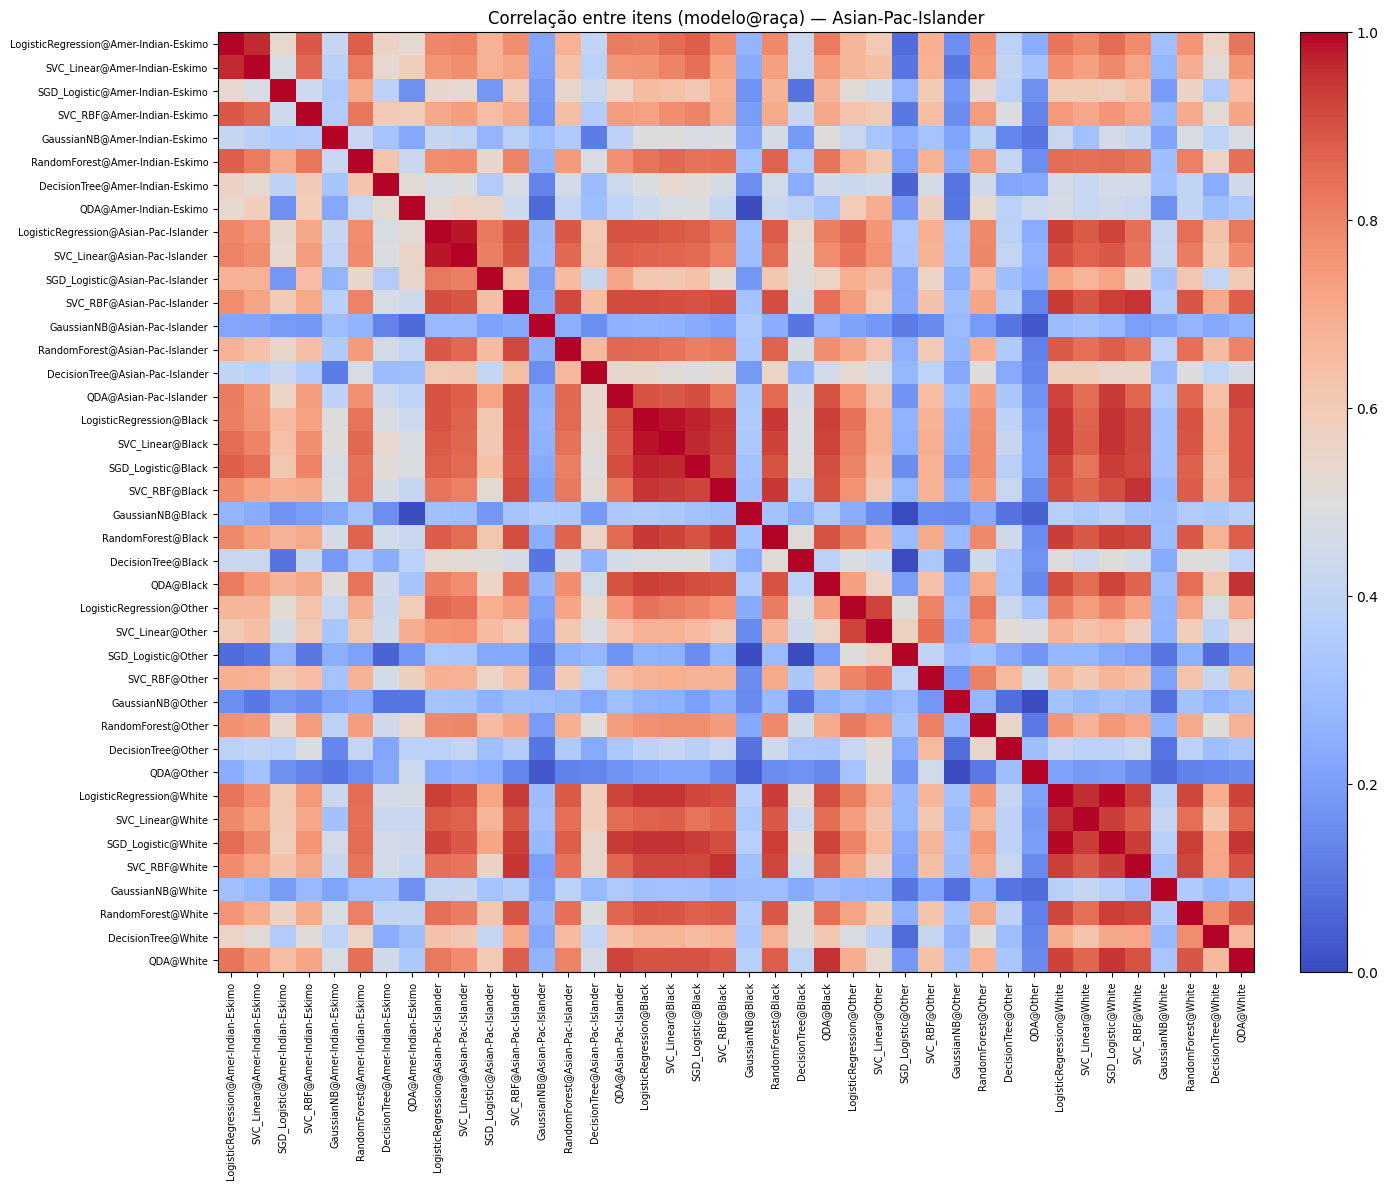

Exportado: correlacoes\corr_teste_Asian-Pac-Islander.csv

Base: Black — 313 instâncias | corr 40x40


,LogisticRegression@Amer-Indian-Eskimo,SVC_Linear@Amer-Indian-Eskimo,SGD_Logistic@Amer-Indian-Eskimo,SVC_RBF@Amer-Indian-Eskimo,GaussianNB@Amer-Indian-Eskimo,RandomForest@Amer-Indian-Eskimo,DecisionTree@Amer-Indian-Eskimo,QDA@Amer-Indian-Eskimo
LogisticRegression@Amer-Indian-Eskimo,1.000,0.950,0.798,0.828,0.331,0.814,0.364,0.442
SVC_Linear@Amer-Indian-Eskimo,0.950,1.000,0.728,0.811,0.377,0.806,0.368,0.525
SGD_Logistic@Amer-Indian-Eskimo,0.798,0.728,1.000,0.560,0.244,0.650,0.198,0.306
SVC_RBF@Amer-Indian-Eskimo,0.828,0.811,0.560,1.000,0.170,0.732,0.411,0.519
GaussianNB@Amer-Indian-Eskimo,0.331,0.377,0.244,0.170,1.000,0.369,0.142,0.091
RandomForest@Amer-Indian-Eskimo,0.814,0.806,0.650,0.732,0.369,1.000,0.504,0.359
DecisionTree@Amer-Indian-Eskimo,0.364,0.368,0.198,0.411,0.142,0.504,1.000,0.273
QDA@Amer-Indian-Eskimo,0.442,0.525,0.306,0.519,0.091,0.359,0.273,1.000


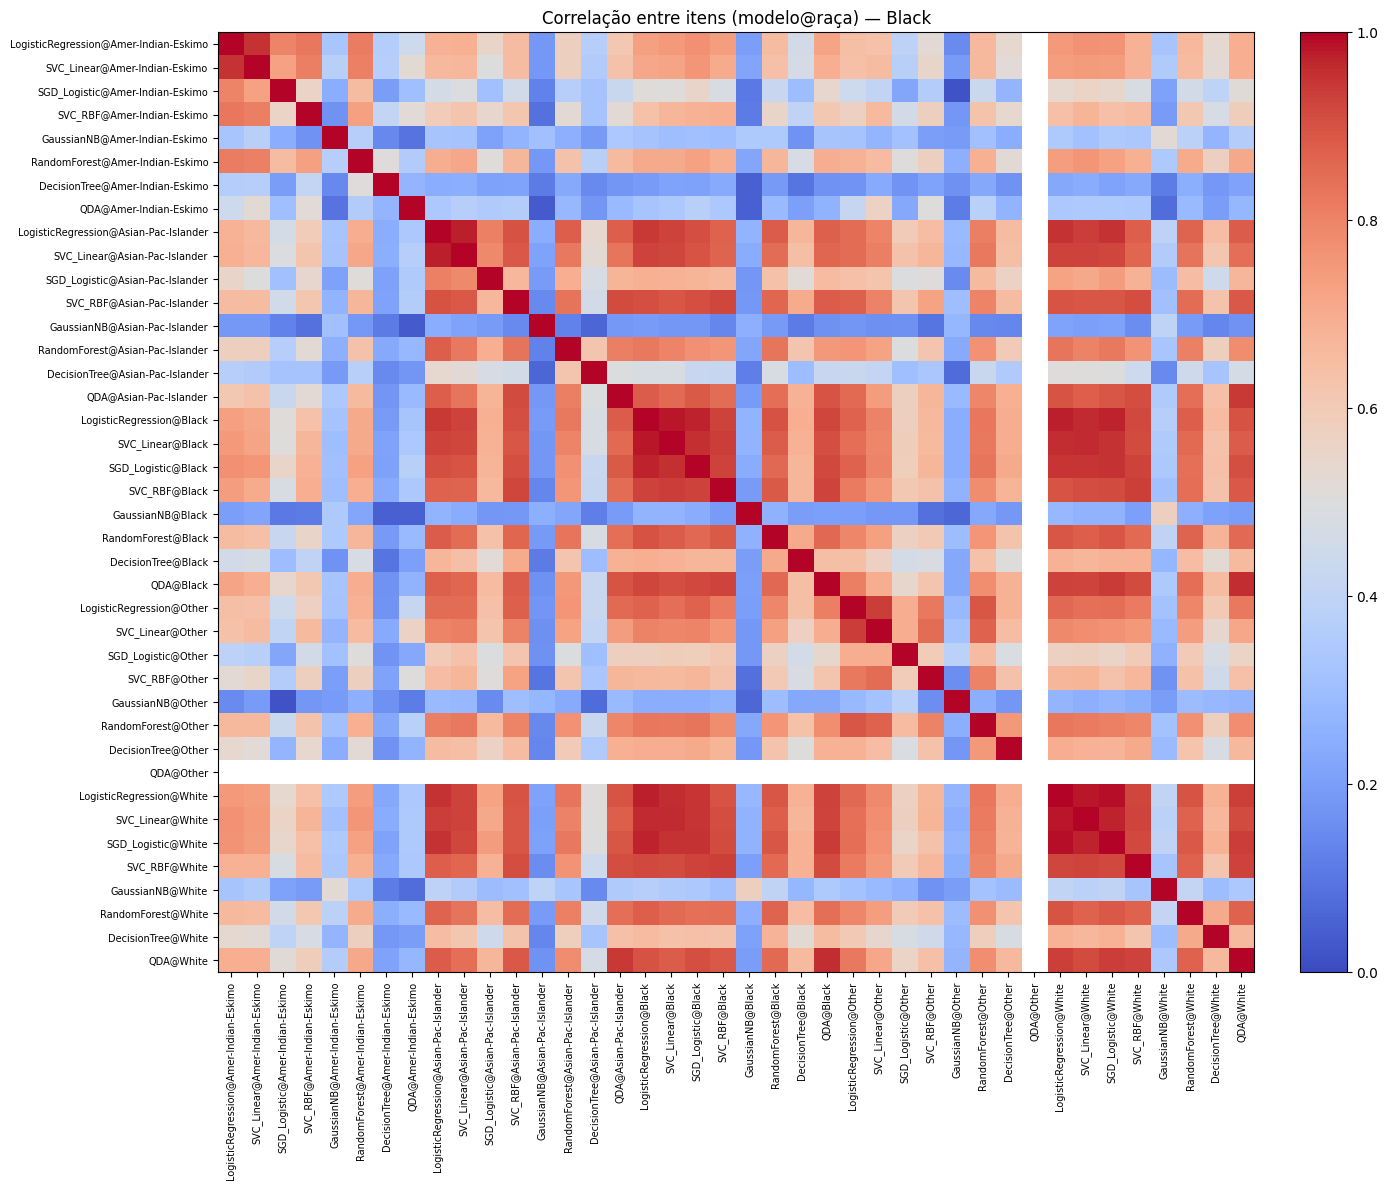

Exportado: correlacoes\corr_teste_Black.csv

Base: Other — 27 instâncias | corr 40x40


,LogisticRegression@Amer-Indian-Eskimo,SVC_Linear@Amer-Indian-Eskimo,SGD_Logistic@Amer-Indian-Eskimo,SVC_RBF@Amer-Indian-Eskimo,GaussianNB@Amer-Indian-Eskimo,RandomForest@Amer-Indian-Eskimo,DecisionTree@Amer-Indian-Eskimo,QDA@Amer-Indian-Eskimo
LogisticRegression@Amer-Indian-Eskimo,1.000,0.969,0.666,0.884,0.478,0.775,0.571,0.773
SVC_Linear@Amer-Indian-Eskimo,0.969,1.000,0.722,0.919,0.534,0.839,0.668,0.849
SGD_Logistic@Amer-Indian-Eskimo,0.666,0.722,1.000,0.686,0.347,0.799,0.460,0.695
SVC_RBF@Amer-Indian-Eskimo,0.884,0.919,0.686,1.000,0.334,0.900,0.632,0.918
GaussianNB@Amer-Indian-Eskimo,0.478,0.534,0.347,0.334,1.000,0.392,0.341,0.237
RandomForest@Amer-Indian-Eskimo,0.775,0.839,0.799,0.900,0.392,1.000,0.605,0.785
DecisionTree@Amer-Indian-Eskimo,0.571,0.668,0.460,0.632,0.341,0.605,1.000,0.693
QDA@Amer-Indian-Eskimo,0.773,0.849,0.695,0.918,0.237,0.785,0.693,1.000


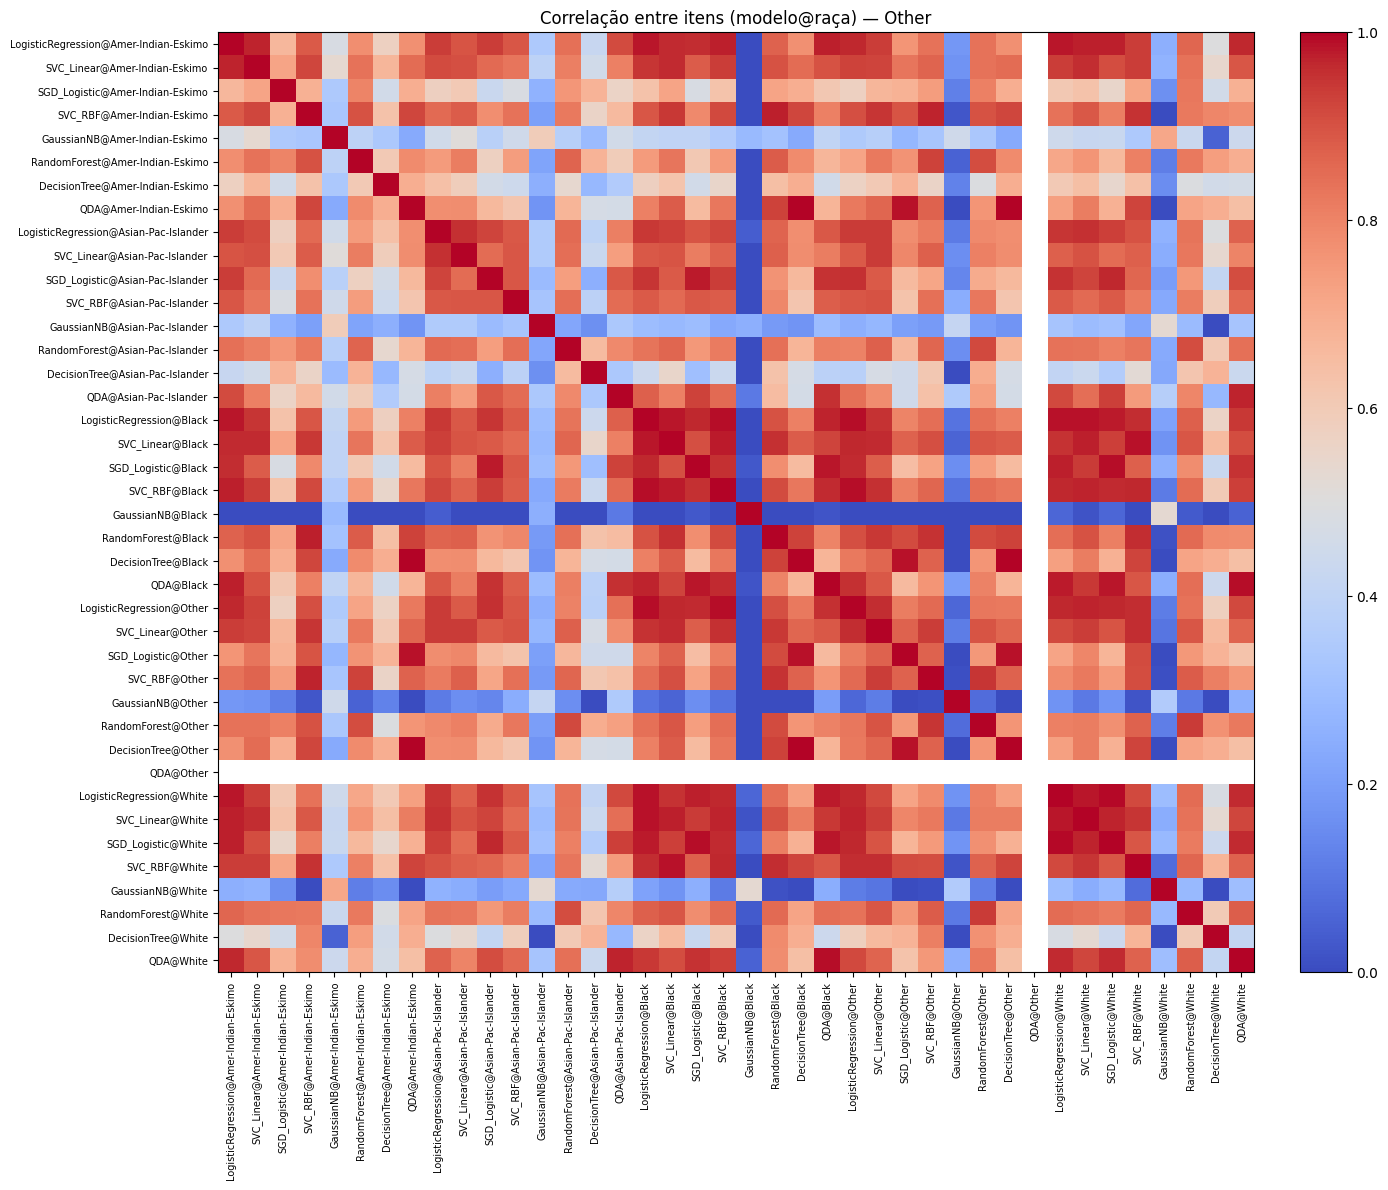

Exportado: correlacoes\corr_teste_Other.csv

Base: White — 2782 instâncias | corr 40x40


,LogisticRegression@Amer-Indian-Eskimo,SVC_Linear@Amer-Indian-Eskimo,SGD_Logistic@Amer-Indian-Eskimo,SVC_RBF@Amer-Indian-Eskimo,GaussianNB@Amer-Indian-Eskimo,RandomForest@Amer-Indian-Eskimo,DecisionTree@Amer-Indian-Eskimo,QDA@Amer-Indian-Eskimo
LogisticRegression@Amer-Indian-Eskimo,1.000,0.942,0.719,0.889,0.357,0.854,0.594,0.545
SVC_Linear@Amer-Indian-Eskimo,0.942,1.000,0.639,0.854,0.343,0.802,0.563,0.638
SGD_Logistic@Amer-Indian-Eskimo,0.719,0.639,1.000,0.604,0.284,0.729,0.513,0.336
SVC_RBF@Amer-Indian-Eskimo,0.889,0.854,0.604,1.000,0.241,0.785,0.620,0.580
GaussianNB@Amer-Indian-Eskimo,0.357,0.343,0.284,0.241,1.000,0.405,0.201,0.092
RandomForest@Amer-Indian-Eskimo,0.854,0.802,0.729,0.785,0.405,1.000,0.647,0.436
DecisionTree@Amer-Indian-Eskimo,0.594,0.563,0.513,0.620,0.201,0.647,1.000,0.411
QDA@Amer-Indian-Eskimo,0.545,0.638,0.336,0.580,0.092,0.436,0.411,1.000


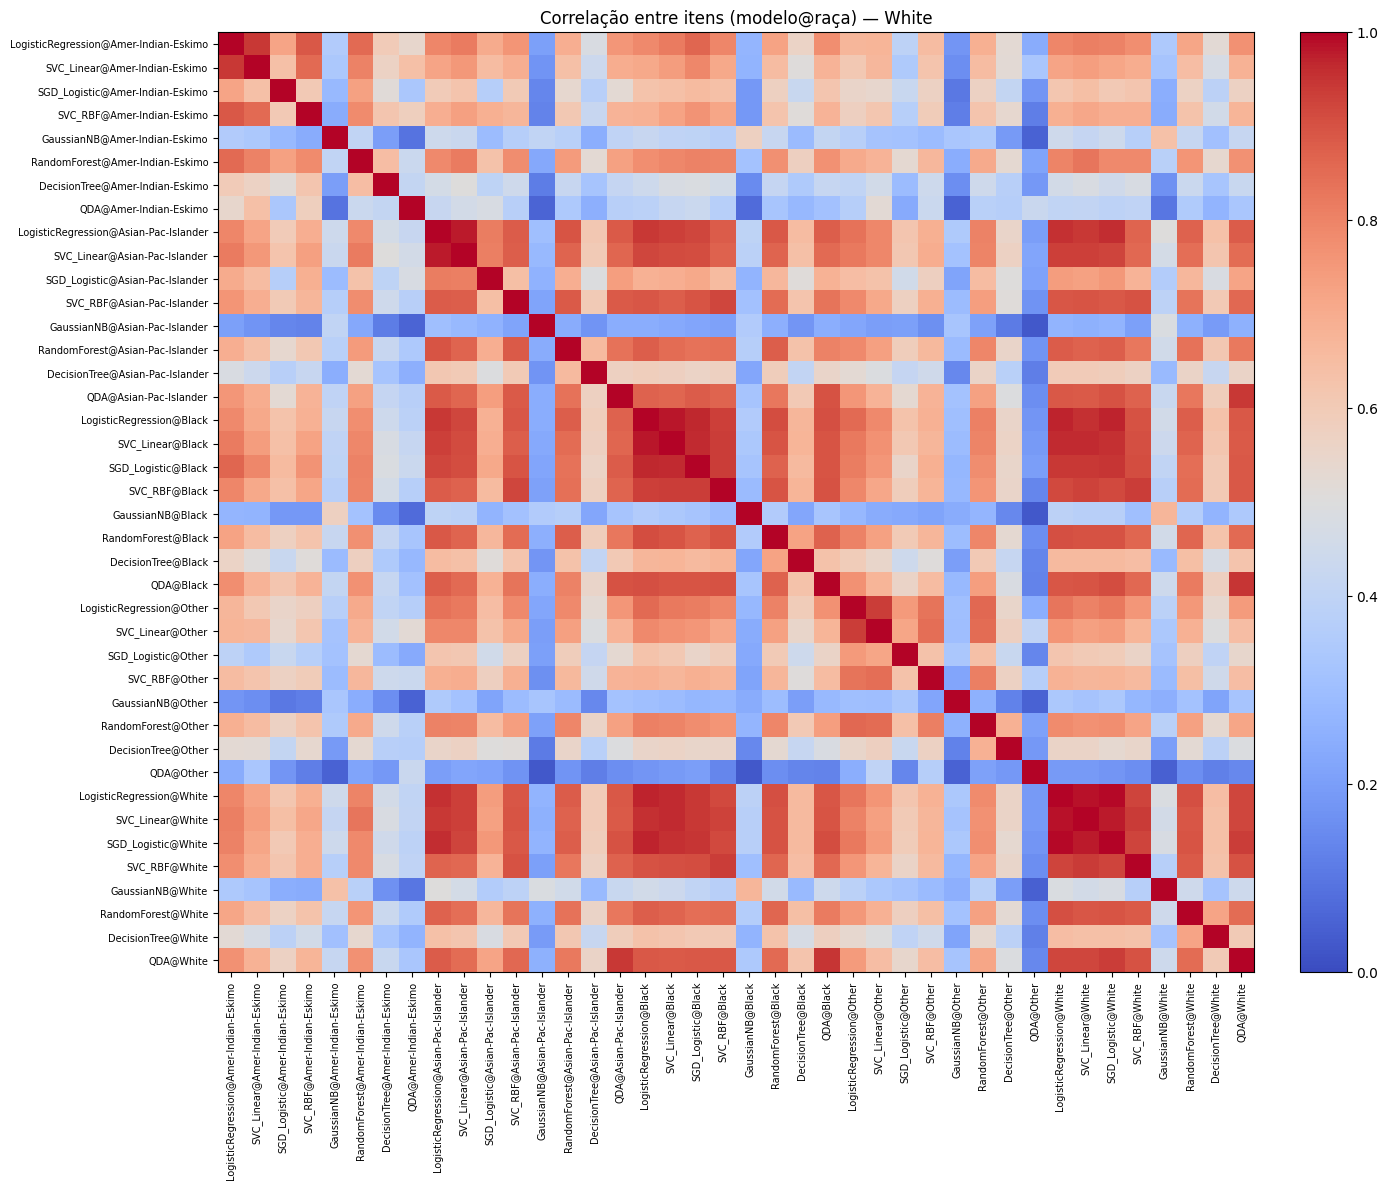

Exportado: correlacoes\corr_teste_White.csv


In [8]:
def plot_corr_itens(corr, titulo, figsize=(14, 12)):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(corr.values, cmap="coolwarm", vmin=0, vmax=1, aspect="auto")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    labels = corr.columns.tolist()
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()


def bases_para_corr(df):
    bases = {slug_base: df}
    if BASE_TESTE == "all":
        for raca in sorted(df["race"].unique()):
            bases[slug_raca(raca)] = df[df["race"] == raca]
    return bases


corrs = {}
for nome, instancias in bases_para_corr(test_df).items():
    if len(instancias) < 2:
        print(f"Pulando {nome}: poucas instâncias")
        continue
    mat = construir_matriz_probabilidades(instancias)
    corr = mat.T.corr().round(3)
    corrs[nome] = corr

    label = "todas as raças" if nome == "all" else nome
    print(f"\n{'=' * 60}")
    print(f"Base: {label} — {len(instancias)} instâncias | corr {corr.shape[0]}x{corr.shape[1]}")
    display(corr.iloc[:8, :8])
    plot_corr_itens(corr, f"Correlação entre itens (modelo@raça) — {label}")

    out = OUTPUT_DIR / f"corr_teste_{nome}.csv"
    corr.to_csv(out)
    print(f"Exportado: {out}")

corr_base = corrs[slug_base]


## 9. Concordância entre modelos (reordenação)

Reordena a correlação da base filtrada por clustering hierárquico (distância = 1 − correlação).


Base: todas as raças — 40 itens
Reordenação: clustering (average), distância = 1 - correlação



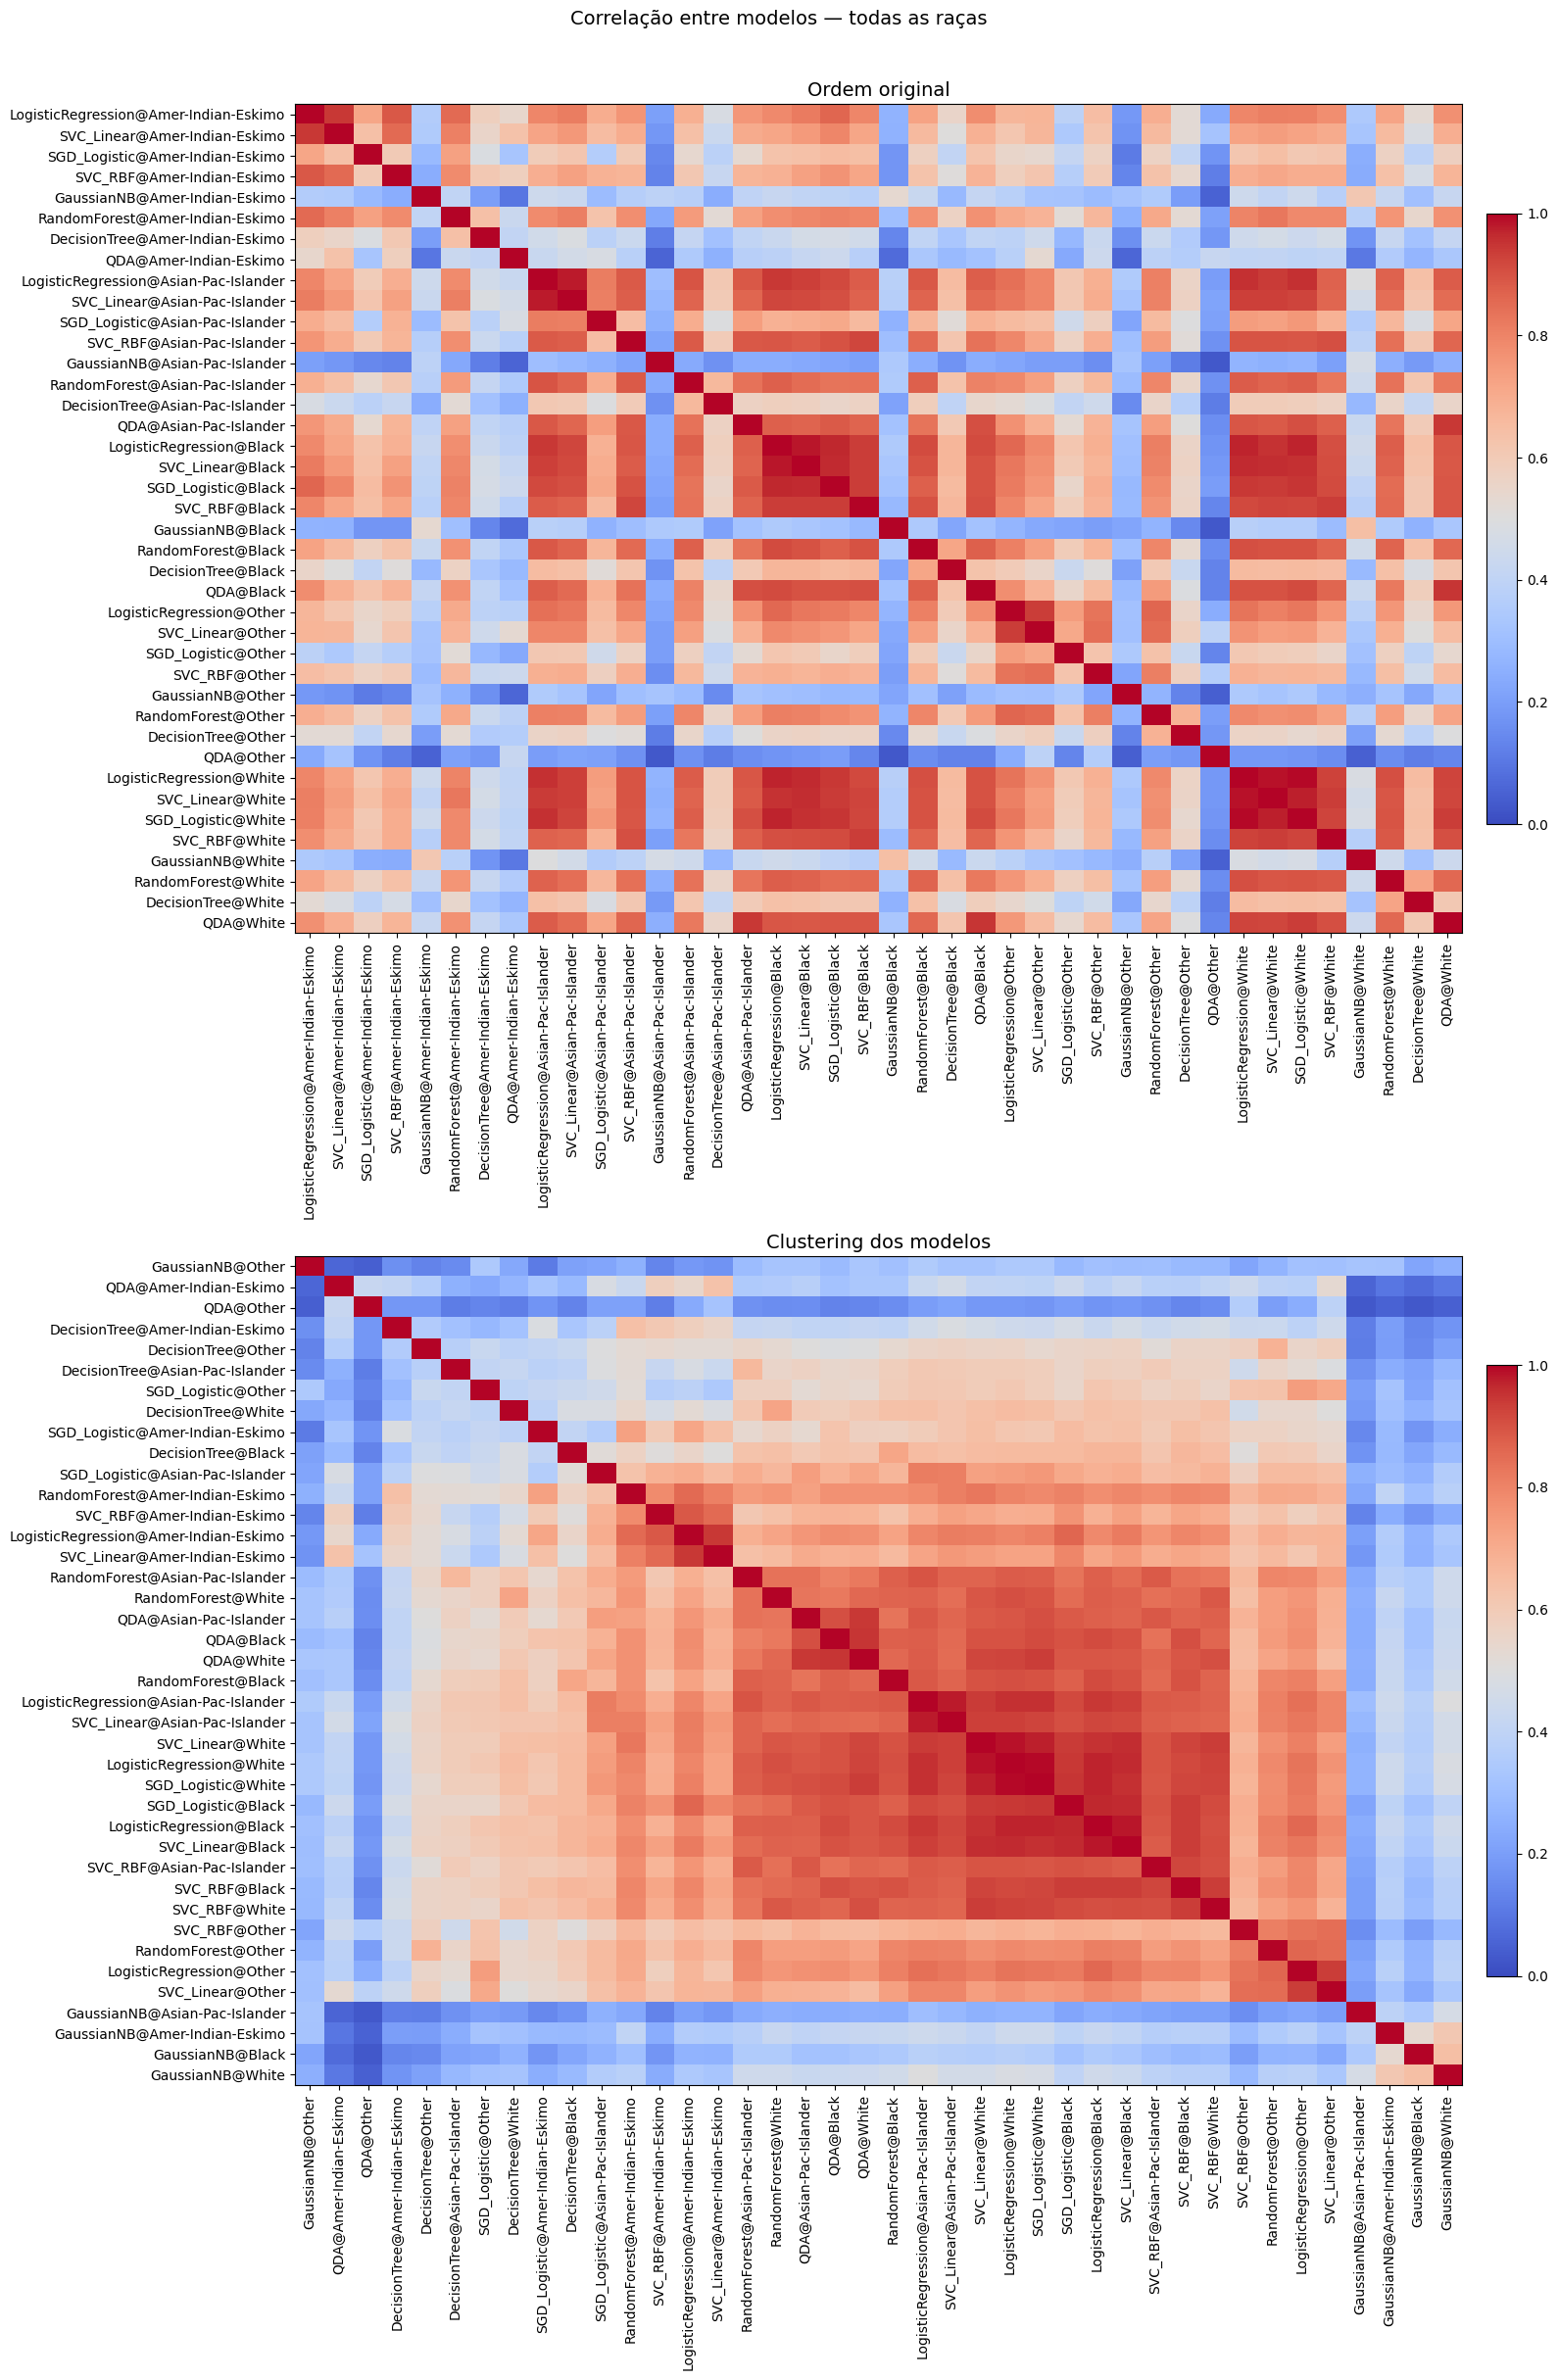

Exportado: correlacoes\corr_teste_all_reordenada.csv


In [9]:
def reordenar_corr_por_concordancia(corr, method=LINKAGE_METHOD):
    dist = 1 - corr.to_numpy(dtype=float)
    np.fill_diagonal(dist, 0)
    dist = np.clip(dist, 0, None)
    ordem = leaves_list(linkage(squareform(dist, checks=False), method=method))
    labels = corr.index[ordem]
    return corr.loc[labels, labels]


def plot_corr_comparacao(corr_orig, corr_ord, titulo, figsize=(16, 24)):
    fig, axes = plt.subplots(2, 1, figsize=figsize)
    for ax, mat, subtitulo in [
        (axes[0], corr_orig, "Ordem original"),
        (axes[1], corr_ord, "Clustering dos modelos"),
    ]:
        im = ax.imshow(mat.to_numpy(dtype=float), cmap="coolwarm", vmin=0, vmax=1, aspect="auto")
        labels = mat.columns.tolist()
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=90, fontsize=10)
        ax.set_yticklabels(labels, fontsize=10)
        ax.set_title(subtitulo, fontsize=14)
        fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    fig.suptitle(titulo, y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()


corr_reordenada = reordenar_corr_por_concordancia(corr_base)
print(f"Base: {label_base} — {corr_base.shape[0]} itens")
print(f"Reordenação: clustering ({LINKAGE_METHOD}), distância = 1 - correlação\n")

plot_corr_comparacao(
    corr_base,
    corr_reordenada,
    f"Correlação entre modelos — {label_base}",
)

out_reord = OUTPUT_DIR / f"corr_teste_{slug_base}_reordenada.csv"
corr_reordenada.to_csv(out_reord)
print(f"Exportado: {out_reord}")


## 10. Descartar instâncias de alta concordância

Remove instâncias em que os 40 modelos concordam demais (baixa dispersão das probabilidades),
recalcula a correlação e reordena.

- Critério: desvio-padrão das 40 probs por instância
- `PERCENTIL_MANTER`: mantém dispersão ≥ percentil


Instâncias — total: 3257 | mantidas: 1629 | removidas: 1628
Percentil 50 → dispersão mínima: 0.3021



,dispersao,status
20079,0.4002,mantida
12584,0.3986,mantida
14406,0.3979,mantida
16326,0.3951,mantida
28161,0.3908,mantida
8437,0.3897,mantida
13410,0.3894,mantida
2014,0.3889,mantida
824,0.3882,mantida
4885,0.3879,mantida


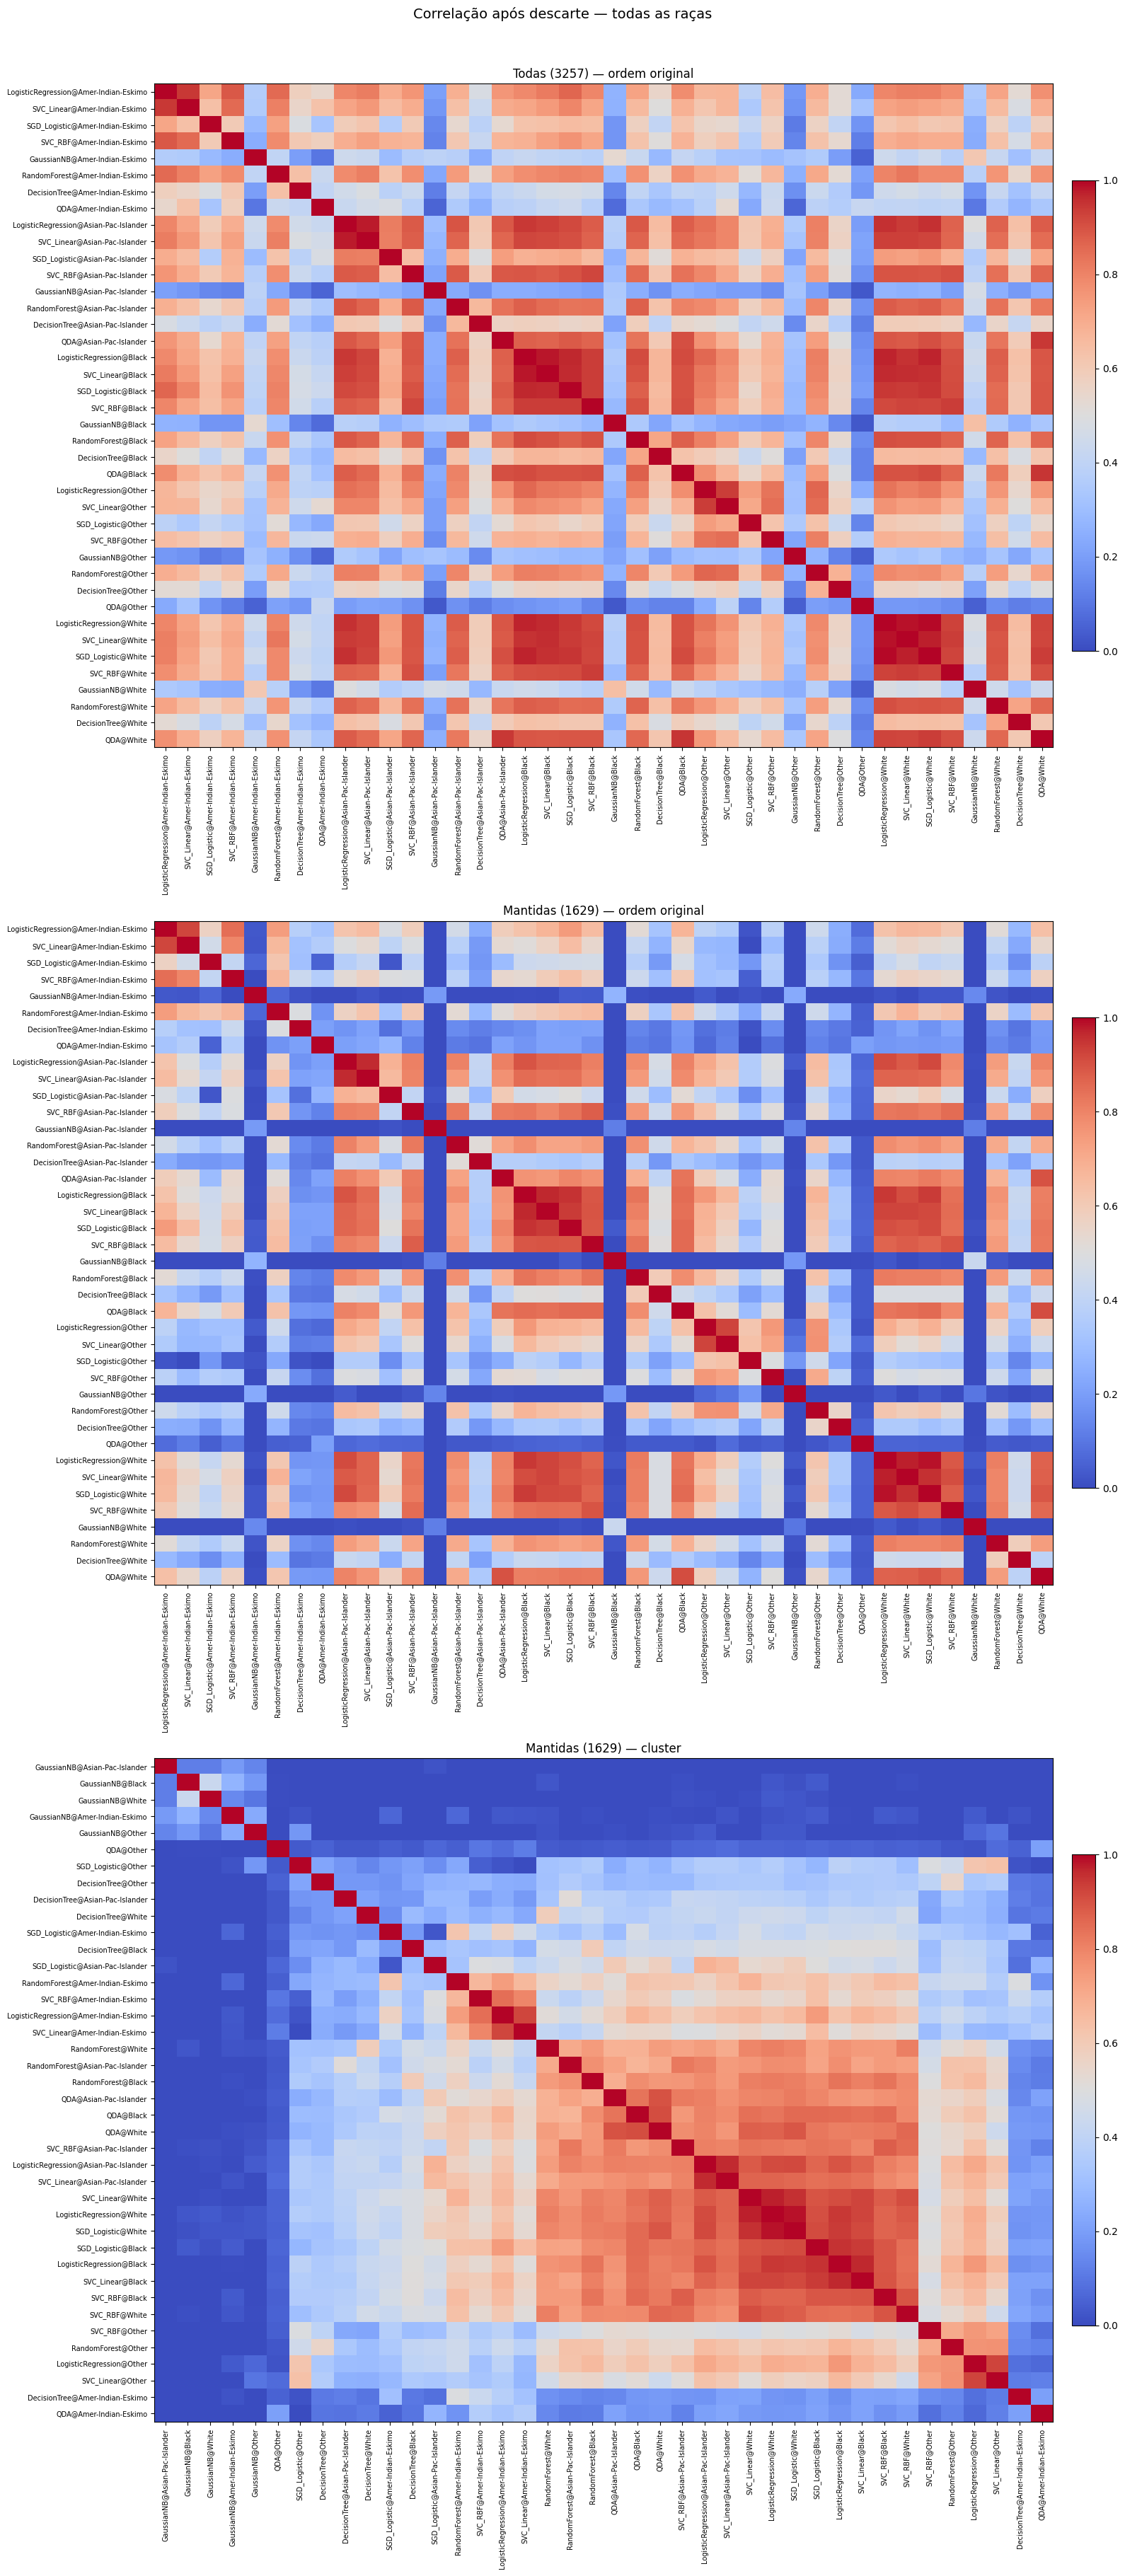

Exportados CSVs de instâncias mantidas e correlações filtradas.


In [10]:
def dispersao_por_instancia(matriz):
    return matriz.std(axis=0).round(4)


def plot_corr_painel(mat, subtitulo, ax):
    im = ax.imshow(mat.to_numpy(dtype=float), cmap="coolwarm", vmin=0, vmax=1, aspect="auto")
    labels = mat.columns.tolist()
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(subtitulo, fontsize=12)
    return im


def plot_corr_painels(painels, titulo, figsize=(16, 36)):
    fig, axes = plt.subplots(len(painels), 1, figsize=figsize)
    if len(painels) == 1:
        axes = [axes]
    for ax, (mat, subtitulo) in zip(axes, painels):
        im = plot_corr_painel(mat, subtitulo, ax)
        fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    fig.suptitle(titulo, y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()


dispersao = dispersao_por_instancia(matriz_prob)
limiar = np.percentile(dispersao, PERCENTIL_MANTER)
instancias_mantidas = dispersao[dispersao >= limiar].index.tolist()
instancias_removidas = dispersao[dispersao < limiar].index.tolist()

if len(instancias_mantidas) < 2:
    raise ValueError("Menos de 2 instâncias mantidas — reduza PERCENTIL_MANTER.")

matriz_filtrada = matriz_prob.loc[:, instancias_mantidas]
corr_filtrada = matriz_filtrada.T.corr().round(3)
corr_filtrada_reord = reordenar_corr_por_concordancia(corr_filtrada)

print(
    f"Instâncias — total: {matriz_prob.shape[1]} | mantidas: {len(instancias_mantidas)} "
    f"| removidas: {len(instancias_removidas)}"
)
print(f"Percentil {PERCENTIL_MANTER} → dispersão mínima: {limiar:.4f}\n")

display(
    pd.DataFrame(
        {"dispersao": dispersao, "status": np.where(dispersao >= limiar, "mantida", "removida")}
    )
    .sort_values("dispersao", ascending=False)
    .head(15)
)

plot_corr_painels(
    [
        (corr_base, f"Todas ({matriz_prob.shape[1]}) — ordem original"),
        (corr_filtrada, f"Mantidas ({len(instancias_mantidas)}) — ordem original"),
        (corr_filtrada_reord, f"Mantidas ({len(instancias_mantidas)}) — cluster"),
    ],
    f"Correlação após descarte — {label_base}",
)

pd.Series(instancias_mantidas, name="instancia_id").to_csv(
    OUTPUT_DIR / f"instancias_mantidas_{slug_base}.csv", index=False
)
corr_filtrada.to_csv(OUTPUT_DIR / f"corr_{slug_base}_instancias_filtradas.csv")
corr_filtrada_reord.to_csv(OUTPUT_DIR / f"corr_{slug_base}_instancias_filtradas_reordenada.csv")
print("Exportados CSVs de instâncias mantidas e correlações filtradas.")


## 11. Análise fatorial da correlação

Scree plot (Kaiser λ ≥ 1), atribuição de itens a fatores e heatmap agrupado.
Usa a correlação da **base filtrada** (todas as instâncias do filtro).


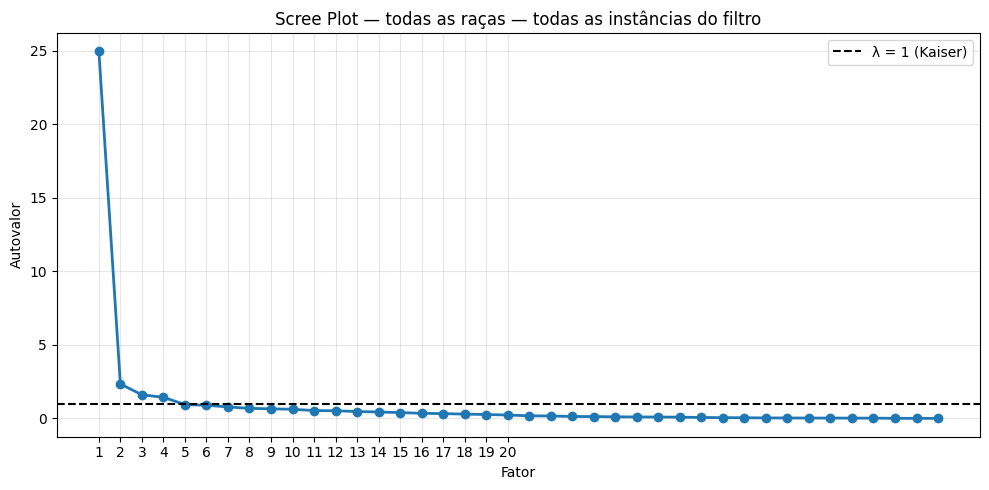

,fator,autovalor,kaiser
0,1,24.9542,True
1,2,2.3371,True
2,3,1.6068,True
3,4,1.4316,True
4,5,0.9426,False
5,6,0.8907,False
6,7,0.7797,False
7,8,0.6826,False
8,9,0.6492,False
9,10,0.6207,False


Fatores sugeridos (Kaiser, λ ≥ 1): 4



,item,fator,carga_max,carga_F1,carga_F2,carga_F3,carga_F4
32,LogisticRegression@White,1,0.969,0.969,0.083,-0.097,-0.030
34,SGD_Logistic@White,1,0.966,0.966,0.085,-0.109,-0.056
33,SVC_Linear@White,1,0.964,0.964,0.046,-0.096,-0.080
16,LogisticRegression@Black,1,0.962,0.962,0.057,-0.132,-0.004
8,LogisticRegression@Asian-Pac-Islander,1,0.961,0.961,0.081,-0.040,0.017
17,SVC_Linear@Black,1,0.959,0.959,0.010,-0.102,-0.047
18,SGD_Logistic@Black,1,0.956,0.956,-0.041,-0.077,-0.098
9,SVC_Linear@Asian-Pac-Islander,1,0.953,0.953,0.017,0.008,0.004
19,SVC_RBF@Black,1,0.937,0.937,-0.010,-0.174,-0.083
35,SVC_RBF@White,1,0.926,0.926,-0.006,-0.159,-0.109


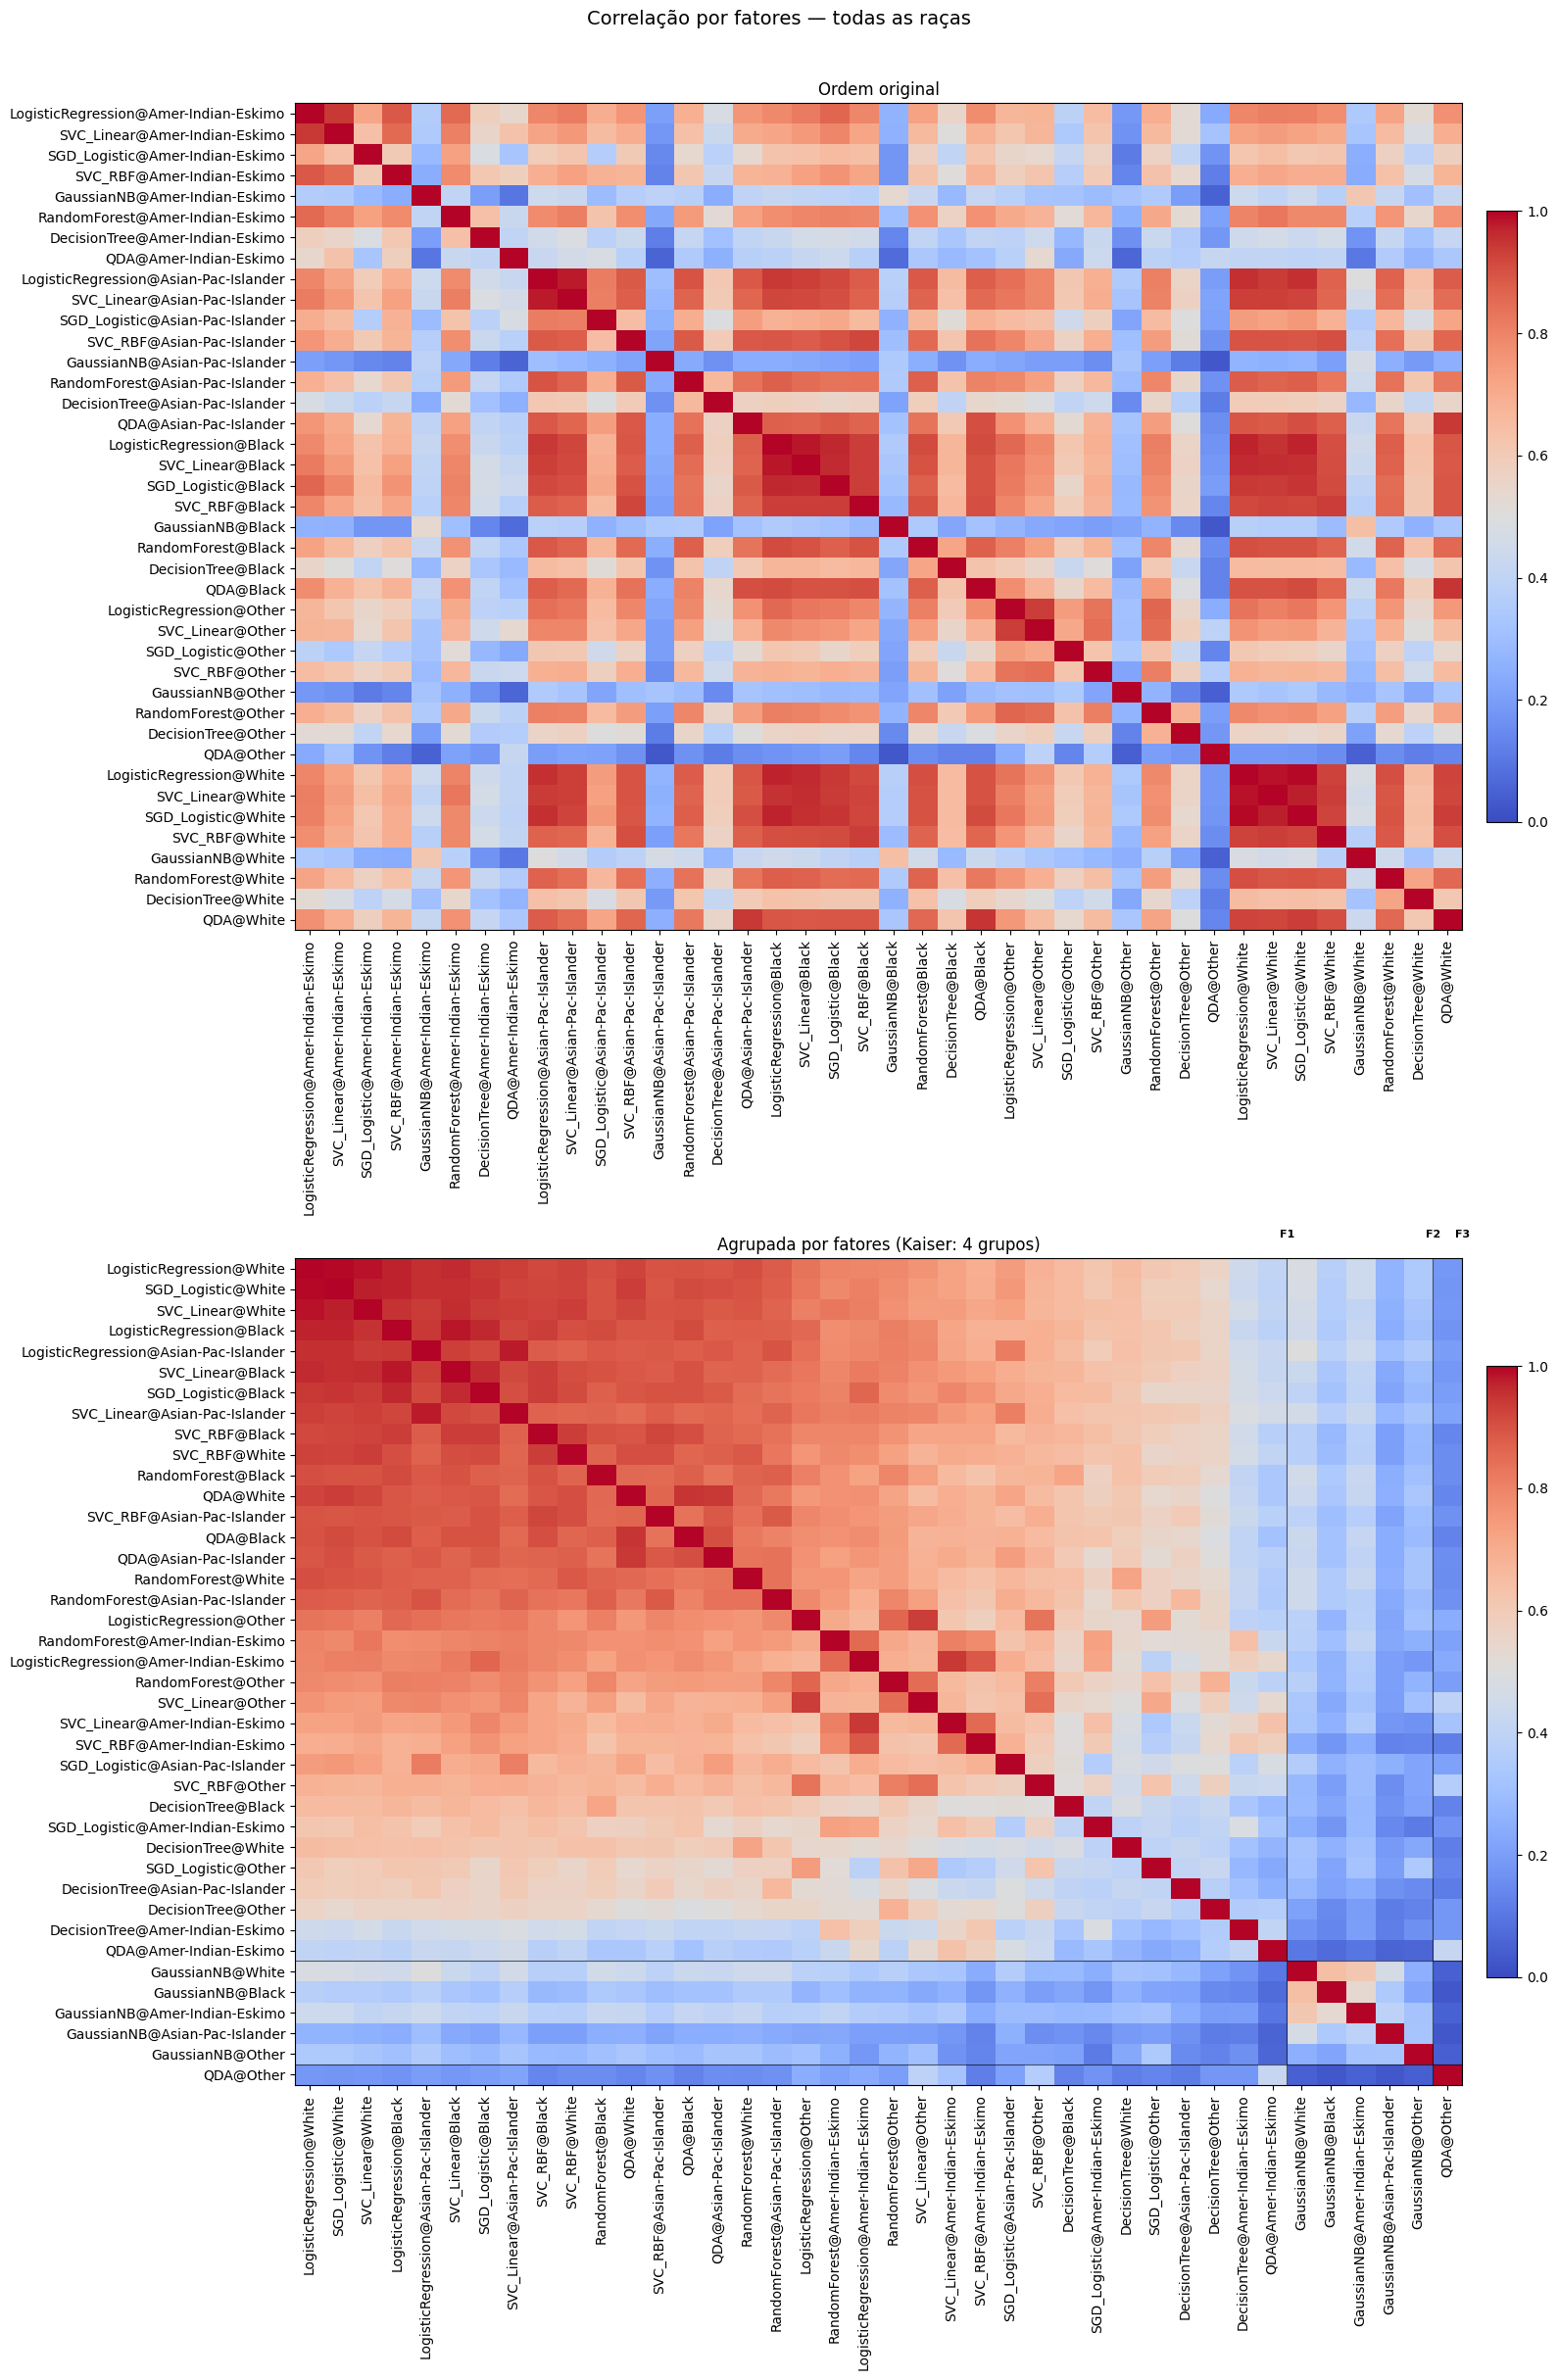

Exportado: fatores / corr por fator / autovalores (all)


In [11]:
def autovalores_corr(corr):
    eigenvalues = np.linalg.eigvalsh(corr.to_numpy(dtype=float))
    return np.sort(eigenvalues)[::-1]


def scree_plot(eigenvalues, titulo):
    n_fatores_kaiser = int((eigenvalues >= 1).sum())
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker="o", linewidth=2)
    ax.axhline(y=1, color="black", linestyle="--", linewidth=1.5, label="λ = 1 (Kaiser)")
    ax.set_xticks(range(1, min(len(eigenvalues) + 1, 21)))
    ax.set_xlabel("Fator")
    ax.set_ylabel("Autovalor")
    ax.set_title(f"Scree Plot — {titulo}")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    display(
        pd.DataFrame(
            {
                "fator": range(1, len(eigenvalues) + 1),
                "autovalor": np.round(eigenvalues, 4),
                "kaiser": eigenvalues >= 1,
            }
        ).head(15)
    )
    print(f"Fatores sugeridos (Kaiser, λ ≥ 1): {n_fatores_kaiser}\n")
    return max(n_fatores_kaiser, 1)


def cargas_fatoriais(corr, n_fatores):
    evals, evecs = np.linalg.eigh(corr.to_numpy(dtype=float))
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]
    n_fatores = min(n_fatores, len(evals))
    loadings = evecs[:, :n_fatores] * np.sqrt(np.maximum(evals[:n_fatores], 0))
    return loadings


def atribuir_fatores(corr, n_fatores):
    itens = corr.index.tolist()
    loadings = cargas_fatoriais(corr, n_fatores)
    fator = np.argmax(np.abs(loadings), axis=1) + 1
    carga_max = np.max(np.abs(loadings), axis=1)

    tabela = pd.DataFrame({"item": itens, "fator": fator, "carga_max": np.round(carga_max, 3)})
    for k in range(loadings.shape[1]):
        tabela[f"carga_F{k + 1}"] = np.round(loadings[:, k], 3)

    ordem_idx = sorted(range(len(itens)), key=lambda i: (fator[i], -carga_max[i]))
    ordem = [itens[i] for i in ordem_idx]
    fatores_ord = fator[ordem_idx]
    return (
        tabela.sort_values(["fator", "carga_max"], ascending=[True, False]),
        ordem,
        fatores_ord,
    )


def plot_corr_fatores(corr_orig, corr_ord, fatores_ord, n_fatores, titulo, figsize=(16, 24)):
    fig, axes = plt.subplots(2, 1, figsize=figsize)
    for ax, mat, subtitulo in [
        (axes[0], corr_orig, "Ordem original"),
        (axes[1], corr_ord, f"Agrupada por fatores (Kaiser: {n_fatores} grupos)"),
    ]:
        im = ax.imshow(mat.to_numpy(dtype=float), cmap="coolwarm", vmin=0, vmax=1, aspect="auto")
        labels = mat.columns.tolist()
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=90, fontsize=10)
        ax.set_yticklabels(labels, fontsize=10)
        ax.set_title(subtitulo, fontsize=12)
        fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)

    ax = axes[1]
    inicio = 0
    for i in range(1, len(fatores_ord)):
        if fatores_ord[i] != fatores_ord[i - 1]:
            ax.axhline(i - 0.5, color="black", linewidth=0.8, alpha=0.6)
            ax.axvline(i - 0.5, color="black", linewidth=0.8, alpha=0.6)
            ax.text(i - 0.5, -1.5, f"F{fatores_ord[inicio]}", ha="center", fontsize=8, fontweight="bold")
            inicio = i
    ax.text(
        len(fatores_ord) - 0.5,
        -1.5,
        f"F{fatores_ord[inicio]}",
        ha="center",
        fontsize=8,
        fontweight="bold",
    )

    fig.suptitle(titulo, y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()


eigenvalues = autovalores_corr(corr_base)
n_fatores = scree_plot(eigenvalues, f"{label_base} — todas as instâncias do filtro")

tabela_fatores, ordem, fatores_ord = atribuir_fatores(corr_base, n_fatores)
corr_por_fator = corr_base.loc[ordem, ordem]
display(tabela_fatores)

plot_corr_fatores(
    corr_base,
    corr_por_fator,
    fatores_ord,
    n_fatores,
    f"Correlação por fatores — {label_base}",
)

tabela_fatores.to_csv(OUTPUT_DIR / f"fatores_itens_{slug_base}.csv", index=False)
corr_por_fator.to_csv(OUTPUT_DIR / f"corr_{slug_base}_por_fator.csv")
pd.DataFrame({"fator": range(1, len(eigenvalues) + 1), "autovalor": eigenvalues.round(4)}).to_csv(
    OUTPUT_DIR / f"analise_fatorial_autovalores_{slug_base}.csv", index=False
)
print(f"Exportado: fatores / corr por fator / autovalores ({slug_base})")
